#### **Dimensionality Reduction of Heart Disease Indicators using PCA and t-SNE for pattern exploration**

In [1]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

#### **Load data and preprocess**
- The dataset is a subset and cleaned version of 2022 annual CDC survey data of 400k+ adults related to their health status
- Kaggle link: [CDC Heart Disease Dataset on Kaggle](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease)

In [2]:
# load dataset
heart_disease_df = pd.read_csv('../data/heart_2020_cleaned.csv')
heart_disease_df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
print("Number of rows and columns:", heart_disease_df.shape)
print("----------------")
print(heart_disease_df.info())

Number of rows and columns: (319795, 18)
----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma    

In [4]:
# target and features 
target = 'HeartDisease'

y = heart_disease_df[target]
X = heart_disease_df.drop(columns=[target])

In [5]:
print("Target variable distribution:")
print(y.value_counts())

Target variable distribution:
HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64


In [6]:
# encode categorical variables
cat_cols = X.select_dtypes(include=['object']).columns

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [ ]:
# subsample the data to speed up t-SNE
if X.shape[0] > 30000:
    sample = X.sample(30000, random_state=42)
    y = y.loc[sample.index]
    X = sample

In [8]:
# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature shape:", X_scaled.shape)
features = X.columns

Scaled feature shape: (30000, 17)


In [9]:
# PCA Analysis
n_comp = min(20, X_scaled.shape[1])
print(f"Performing PCA with {n_comp} components")

pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_scaled)

Performing PCA with 17 components


In [10]:
explained = pd.DataFrame({
    "PC": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "Explained_Var_Ratio": pca.explained_variance_ratio_,
})
explained["Cumulative_Explained"] = explained["Explained_Var_Ratio"].cumsum()
print("\nVariance explained (first components):")
print(explained.head(10))


Variance explained (first components):
   PC  Explained_Var_Ratio  Cumulative_Explained
0   1             0.133957              0.133957
1   2             0.091004              0.224961
2   3             0.072956              0.297917
3   4             0.065580              0.363496
4   5             0.062557              0.426053
5   6             0.058614              0.484666
6   7             0.056765              0.541431
7   8             0.055326              0.596758
8   9             0.053450              0.650208
9  10             0.052314              0.702521


**PCA**
- The first 2 components explain approximately 22% of total variance.
- By the 10th component, approximately 70% of total variability is captured. 
- This shows no single dominant direction of variance as typically heatlhcare factors are multifactorial and interrelated.

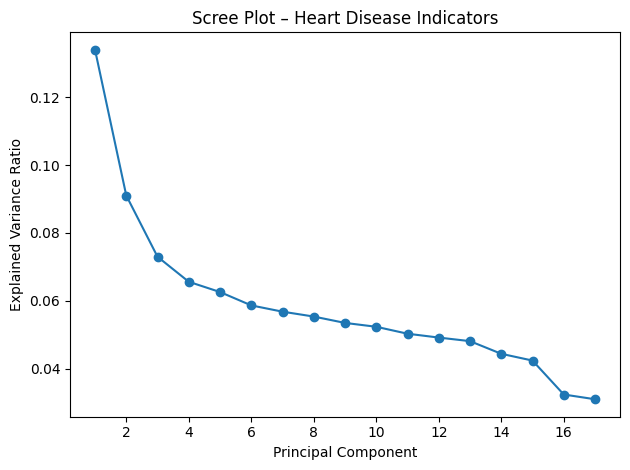

In [11]:
# Scree plot
plt.figure()
plt.plot(explained["PC"], explained["Explained_Var_Ratio"], marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot – Heart Disease Indicators")
plt.tight_layout()
plt.show()

- Scree plot shows the reduction of explained variance value as the principle components increase.

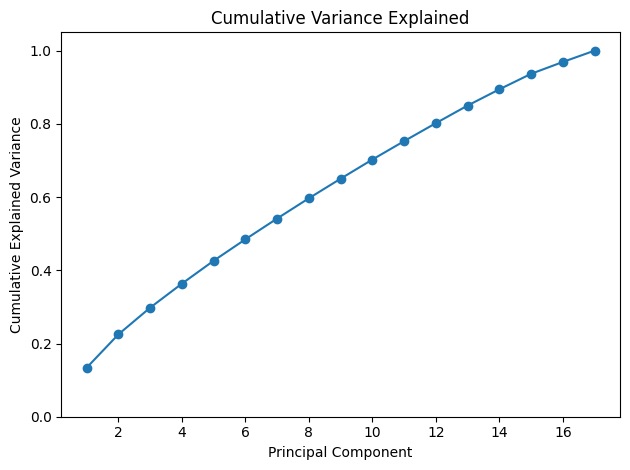

In [12]:
# Cumulative variance plot
plt.figure()
plt.plot(explained["PC"], explained["Cumulative_Explained"], marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [13]:
# Loadings (feature contributions)
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)]
)

def top_features_for_pc(loadings_df, pc='PC1', k=5):
    s = loadings_df[pc].sort_values()
    return pd.DataFrame({
        "Top_Negative": s.head(k),
        "Top_Positive": s.tail(k)
    })

print("\nTop features for PC1 (neg/pos):")
print(top_features_for_pc(loadings, 'PC1', k=5))
print("\nTop features for PC2 (neg/pos):")
print(top_features_for_pc(loadings, 'PC2', k=5))


Top features for PC1 (neg/pos):
                  Top_Negative  Top_Positive
AgeCategory                NaN      0.269057
AlcoholDrinking      -0.029765           NaN
Diabetic                   NaN      0.305499
DiffWalking                NaN      0.479509
GenHealth            -0.027638           NaN
PhysicalActivity     -0.340033           NaN
PhysicalHealth             NaN      0.443630
Sex                  -0.082685           NaN
SleepTime            -0.035013           NaN
Stroke                     NaN      0.233663

Top features for PC2 (neg/pos):
                 Top_Negative  Top_Positive
AgeCategory               NaN      0.538714
AlcoholDrinking     -0.056343           NaN
Asthma              -0.245539           NaN
BMI                 -0.163094           NaN
KidneyDisease             NaN      0.118954
MentalHealth        -0.409344           NaN
PhysicalHealth      -0.169986           NaN
Race                      NaN      0.308967
SkinCancer                NaN      0.425343

**Feature Contributions**
- PC1:
    - This component is mainly representing "physical limitation and health-risk" axis
    - positive side shows the people with difficulty walking, poor physical health, diabetes etc., and on the other hand, negative side shows people with higher physical activity.
    - PC1 separateshealthy active individuals from individuals with chronic or physical conditions.
- PC2:
    - This shows the demographic and psychological health where positive side shows older individuals likely to report skin cancer ot kidney disease and negative side shows mental health challenges.
    - PC2 separates participants by age/medical condition vs mental/respiratory factors.

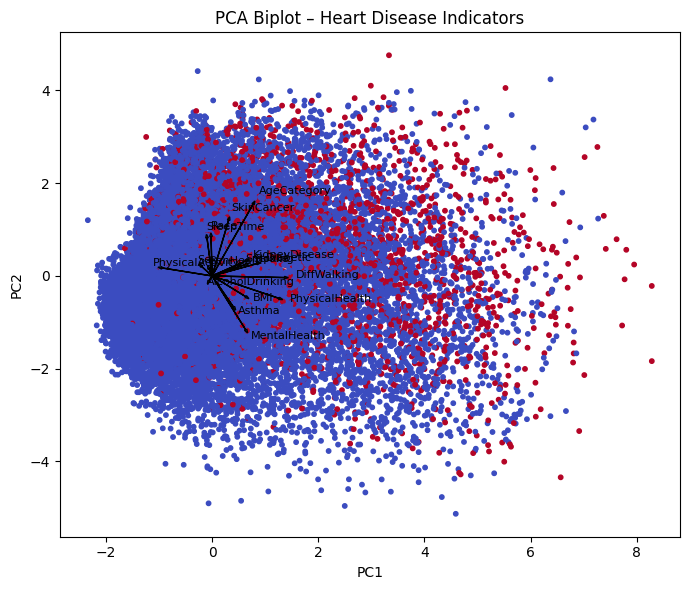

In [14]:
# PCA biplot
pc1, pc2 = 0, 1
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, pc1], X_pca[:, pc2],
            c=(y == 'Yes').astype(int), cmap='coolwarm', s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot – Heart Disease Indicators")
arrow_scale = 3.0
for i, feat in enumerate(features):
    x = pca.components_[pc1, i] * arrow_scale
    y_ = pca.components_[pc2, i] * arrow_scale
    plt.arrow(0, 0, x, y_, head_width=0.05, length_includes_head=True)
    plt.text(x * 1.1, y_ * 1.1, feat, fontsize=8)
plt.tight_layout()
plt.show()

**PCA Biplot**
- This plot shows that the cloud is largely overlapping which means heart disease status cannot be perfectly separated using just 2 components.
- The red points drift slightly to the right suggesting higher PC1 values corresponds to higher disease risk.
- Features like DiffWalking, PhysicalHealth, Diabetic, and Stroke have long arrows toward the red cluster region stating strong indicators of heart disease. 
- Blue cluster corresponds to the healthier individuals. 

t-SNE 

In [15]:
# t-SNE definition
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=300,
    n_iter=1000,
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)

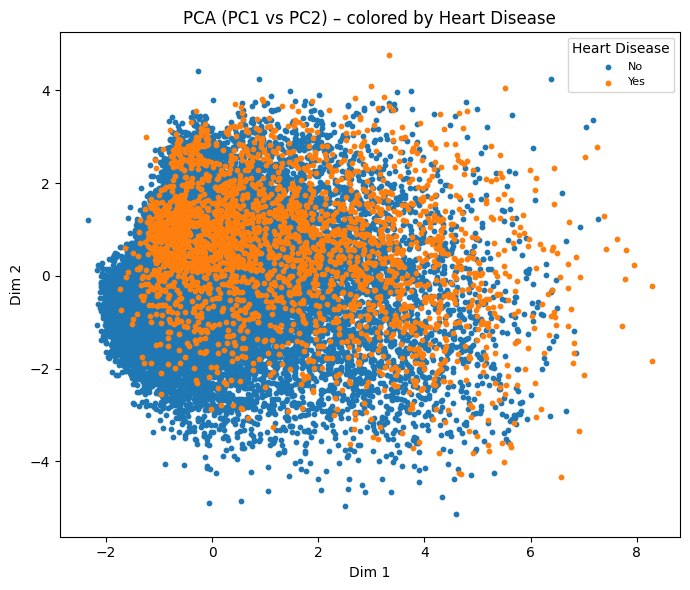

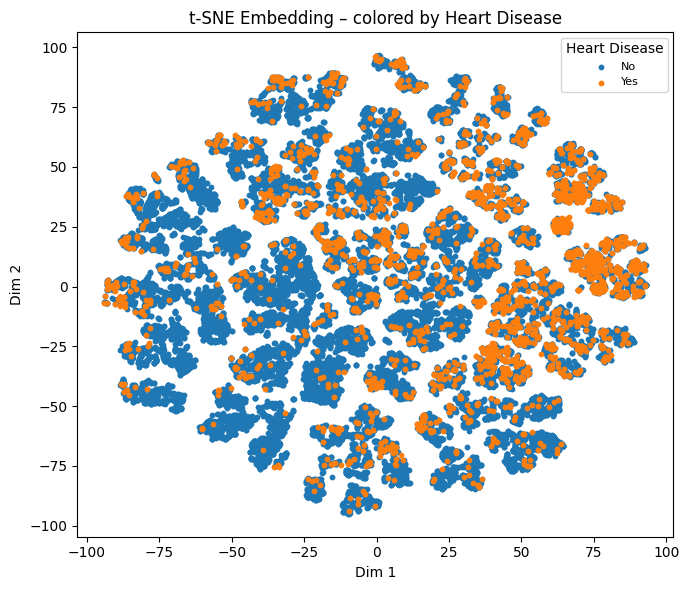

In [16]:
# plots for PCA and t-SNE
def scatter_with_labels(emb2d, labels, title):
    plt.figure(figsize=(7, 6))
    labels = pd.Series(labels).astype('category')
    codes = labels.cat.codes.values
    for c in np.unique(codes):
        mask = (codes == c)
        plt.scatter(emb2d[mask, 0], emb2d[mask, 1], label=str(labels.cat.categories[c]), s=10)
    plt.legend(title="Heart Disease", fontsize=8)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

scatter_with_labels(X_pca[:, :2], y, "PCA (PC1 vs PC2) – colored by Heart Disease")
scatter_with_labels(X_tsne, y, "t-SNE Embedding – colored by Heart Disease")

**PCA scatter plot**
- Orange and blue points overlap which shows no clear separation
- Higher concentration of "Yes" points towards the right proves that heart disease is associated with higher PC1 values and it also shows that heart disease is dependent on multiple factors rather than a single one. 

**t-SNE Embedding**
- t-SNE forms severla dense clusters showing the local similarity groups.
- Blue and orange points shows no perfectly distinct clusters but some clusters have high densities of orange points.
- Compared to PCA, t-SNE reveals more local structure but it still shows overlap between the health indicators.